# 01 Traffic Light Color Space Probe v1

이번 노트북은 **신호등 red / green 색 조합을 찾기 위한 탐색 단계**다.

여기서는 아직 detector를 확정하지 않는다. 즉, 이 노트북의 목적은 다음 질문에 답하는 것이다.

- red 신호와 green 신호가 실제 이미지에서 어떤 색 분포를 가지는가?
- BGR/HSV/HLS/YCrCb/LAB 중 어떤 색공간에서 red와 green이 더 잘 분리되어 보이는가?
- 신호등 불빛은 작은 물체라서 전체 이미지 통계에 묻히는가?
- 느슨한 분석 crop을 걸었을 때 분포가 더 읽히는가?

이 노트북에서 하지 않는 것:

- 최종 HSV threshold 결정
- contour 조건 결정
- ROI contract 결정
- temporal voting 결정
- traffic event trigger 결정

말하자면 01은 **색을 읽는 현미경**이고, detector는 아직 아니다.

## 색공간 개념

OpenCV 색 기반 탐지를 하려면 먼저 색공간을 이해해야 한다.

### BGR / RGB

OpenCV는 기본적으로 이미지를 `BGR` 순서로 읽는다. 우리가 화면에 볼 때는 `RGB`로 바꿔야 자연스럽다.

- `B`: 파란 성분
- `G`: 초록 성분
- `R`: 빨간 성분

장점은 직관적이다. 단점은 조명 변화에 취약하다. 예를 들어 빨간 신호도 어두워지면 `R` 값이 낮아지고, 흰 반사광은 `R/G/B`가 모두 높아진다.

### HSV

HSV는 색 기반 탐지에서 가장 많이 쓰는 색공간이다.

- `H` Hue: 색상 각도. 빨강/초록/파랑 같은 실제 색의 종류
- `S` Saturation: 색의 순도. 회색/흰색에 가까우면 낮고, 진한 색이면 높다
- `V` Value: 밝기

OpenCV의 `H` 범위는 `0~179`다. 중요한 점은 **red가 양 끝에서 끊어진다**는 것이다. 빨강은 보통 `H≈0` 근처와 `H≈179` 근처에 동시에 나타날 수 있다. green은 대체로 중간 영역에 모인다.

### HLS

HLS는 HSV와 비슷하지만 밝기를 `L` Lightness로 표현한다.

- `H`: 색상
- `L`: 밝기/명도
- `S`: 채도

HSV의 `V`가 강한 조명 반사에 민감하면, HLS가 더 안정적으로 보일 때가 있다.

### YCrCb

YCrCb는 밝기와 색차를 나눈다.

- `Y`: 밝기
- `Cr`: red 계열 색차
- `Cb`: blue/yellow 계열 색차

red 신호는 보통 `Cr`에서 잘 튀는 경우가 많다. green은 YCrCb 하나만으로는 HSV만큼 직관적이지 않을 수 있지만, false positive를 줄이는 보조 조건이 될 수 있다.

### LAB

LAB도 밝기와 색을 분리한다.

- `L`: 밝기
- `a`: green ↔ red 축
- `b`: blue ↔ yellow 축

red는 `a` 쪽에서, green은 반대 방향에서 특징이 생긴다. 조명 변화가 있는 환경에서 보조 지표로 쓸 수 있다.

이번 노트북은 이 색공간들을 전부 보고, 다음 노트북에서 실제 threshold 후보를 잡기 위한 근거를 만든다.

In [1]:
from pathlib import Path
import os
import random
import csv
import json
import math
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

EXPERIMENT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector")
DATASET_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset")
TRAFFIC_RAW = DATASET_ROOT / "traffic" / "raw"
RUN_NAME = "01_traffic_color_space_probe_v1"
OUT_DIR = EXPERIMENT_ROOT / "review_outputs" / RUN_NAME
TABLE_DIR = OUT_DIR / "tables"
OVERLAY_DIR = OUT_DIR / "overlays"
NOTE_DIR = OUT_DIR / "notes"

for d in [TABLE_DIR, OVERLAY_DIR, NOTE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 18
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("EXPERIMENT_ROOT:", EXPERIMENT_ROOT)
print("TRAFFIC_RAW:", TRAFFIC_RAW, "exists=", TRAFFIC_RAW.exists())
print("OUT_DIR:", OUT_DIR)

EXPERIMENT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector
TRAFFIC_RAW: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\traffic\raw exists= True
OUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1


## Windows / 한글 경로 helper

이 실험 폴더와 데이터셋 경로에는 한글과 긴 경로가 섞여 있다. 그래서 `cv2.imread()` / `cv2.imwrite()` 대신 아래 helper를 쓴다.

- 읽기: `np.fromfile()` → `cv2.imdecode()`
- 쓰기: `cv2.imencode()` → `tofile()`
- Windows 긴 경로는 필요하면 `\\?\` prefix를 붙인다.

12번 폴더에서 겪었던 경로 문제를 반복하지 않기 위한 장치다.

In [2]:
def fs_path(path):
    path = Path(path)
    s = str(path.resolve())
    if os.name == "nt" and not s.startswith("\\\\?\\"):
        return "\\\\?\\" + s
    return s


def exists_fs(path):
    return Path(fs_path(path)).exists()


def imread_bgr(path):
    path = Path(path)
    data = np.fromfile(fs_path(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"Failed to read image: {path}")
    return img


def imwrite_bgr(path, img, quality=95):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix.lower()
    params = []
    if ext in {".jpg", ".jpeg"}:
        params = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    ok, buf = cv2.imencode(ext, img, params)
    if not ok:
        raise RuntimeError(f"Failed to encode image: {path}")
    buf.tofile(fs_path(path))


def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def write_text(path, text):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")

def read_binary_fs(path):
    with open(fs_path(path), "rb") as f:
        return f.read()


def show_saved_image(path, width=1000):
    """Embed a saved image into the notebook output.

    Image(filename=...) can fail in some Windows/Jupyter frontends when paths are long.
    This reads the file bytes and embeds them directly into the output cell.
    """
    path = Path(path)
    suffix = path.suffix.lower()
    fmt = "png" if suffix == ".png" else "jpeg"
    display(Image(data=read_binary_fs(path), format=fmt, width=width))


## 데이터 index 만들기

00 노트북에서는 traffic/red/green이 정상적으로 들어온 것을 확인했다. 여기서는 traffic만 대상으로 다시 index를 만든다.

이 단계에서도 label은 `red`, `green`만 사용한다. 아직 detector를 만들지 않기 때문에 정답 bbox는 필요 없다.

In [3]:
def iter_images(root):
    root = Path(root)
    if not exists_fs(root):
        return []
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

records = []
for p in iter_images(TRAFFIC_RAW):
    label = p.parent.name.lower()
    if label not in {"red", "green"}:
        continue
    records.append({
        "dataset": "traffic",
        "label": label,
        "path": str(p),
        "rel_path": str(p.relative_to(DATASET_ROOT)),
        "filename": p.name,
    })

traffic_df = pd.DataFrame(records)
traffic_df.to_csv(TABLE_DIR / "traffic_dataset_index.csv", index=False, encoding="utf-8-sig")
print(traffic_df.groupby("label").size())
display(traffic_df.head())
assert len(traffic_df) > 0
assert set(traffic_df["label"].unique()) == {"red", "green"}

label
green    313
red      343
dtype: int64


,dataset,label,path,rel_path,filename
0,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174909_signs_green_...,20260430_174909_signs_green_moving_mixed_right...
1,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174909_signs_green_...,20260430_174909_signs_green_moving_mixed_right...
2,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174909_signs_green_...,20260430_174909_signs_green_moving_mixed_right...
3,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174909_signs_green_...,20260430_174909_signs_green_moving_mixed_right...
4,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174910_signs_green_...,20260430_174910_signs_green_moving_mixed_right...


## 샘플 선택 방식

신호등 불빛은 이미지 전체에서 매우 작은 영역이다. 그래서 전체 이미지 통계만 보면 배경, 차선, 벽, 바닥에 묻힌다.

이번 노트북에서는 두 종류의 관찰을 같이 한다.

1. **전체 프레임 관찰**: 실제 입력 이미지 전체가 어떤 색 분포인지 본다.
2. **느슨한 분석 crop 관찰**: 신호등이 자주 등장하는 오른쪽/중앙 쪽 넓은 영역만 참고용으로 본다.

여기서 crop은 최종 ROI가 아니다. 단지 작은 신호등 픽셀이 배경에 묻히지 않도록 보기 위한 돋보기다.

In [4]:
# 사용자가 필요하면 나중에 여기 값만 바꿔서 다시 볼 수 있다.
# 단, 이 값은 detector contract가 아니다. 색 분포를 보기 위한 분석 crop이다.
SAMPLES_PER_LABEL = 24
ANALYSIS_CROP_RATIO = {
    "x0": 0.35,
    "x1": 1.00,
    "y0": 0.00,
    "y1": 0.82,
}

# 작은 신호등 불빛이 전체 픽셀에 묻히므로, 색이 강하고 밝은 픽셀도 따로 본다.
# 이 역시 threshold 확정이 아니라 분포를 읽기 위한 샘플링 기준이다.
SALIENT_PIXEL_TOP_PERCENT = 0.6   # crop 안에서 S*V가 높은 상위 0.6% 픽셀
MAX_PIXELS_PER_IMAGE = 2500

sample_records = []
for label, sub in traffic_df.groupby("label"):
    n = min(SAMPLES_PER_LABEL, len(sub))
    sampled = sub.sample(n=n, random_state=RANDOM_SEED).to_dict("records")
    sample_records.extend(sampled)

sample_df = pd.DataFrame(sample_records)
sample_df.to_csv(TABLE_DIR / "traffic_color_probe_sample_records.csv", index=False, encoding="utf-8-sig")
print(sample_df.groupby("label").size())
display(sample_df.head())

label
green    24
red      24
dtype: int64


,dataset,label,path,rel_path,filename
0,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260501_123331_07_traffic_c...,20260501_123331_07_traffic_capture_green_01821...
1,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174953_signs_green_...,20260430_174953_signs_green_moving_mixed_right...
2,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174919_signs_green_...,20260430_174919_signs_green_moving_mixed_right...
3,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174910_signs_green_...,20260430_174910_signs_green_moving_mixed_right...
4,traffic,green,~\02_Projects\University\26-1_Em...,traffic\raw\green\20260430_174946_signs_green_...,20260430_174946_signs_green_moving_mixed_right...


## 샘플 grid + 분석 crop 표시

아래 grid는 사람이 먼저 보는 용도다.

- 흰색 박스: 이번 노트북에서 색 분포를 볼 때 사용하는 느슨한 분석 crop
- 이 박스는 최종 ROI가 아니다.
- 신호등이 박스 안에 충분히 들어오는지, crop이 너무 좁거나 넓은지 확인한다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_red_sample_grid_with_analysis_crop.jpg


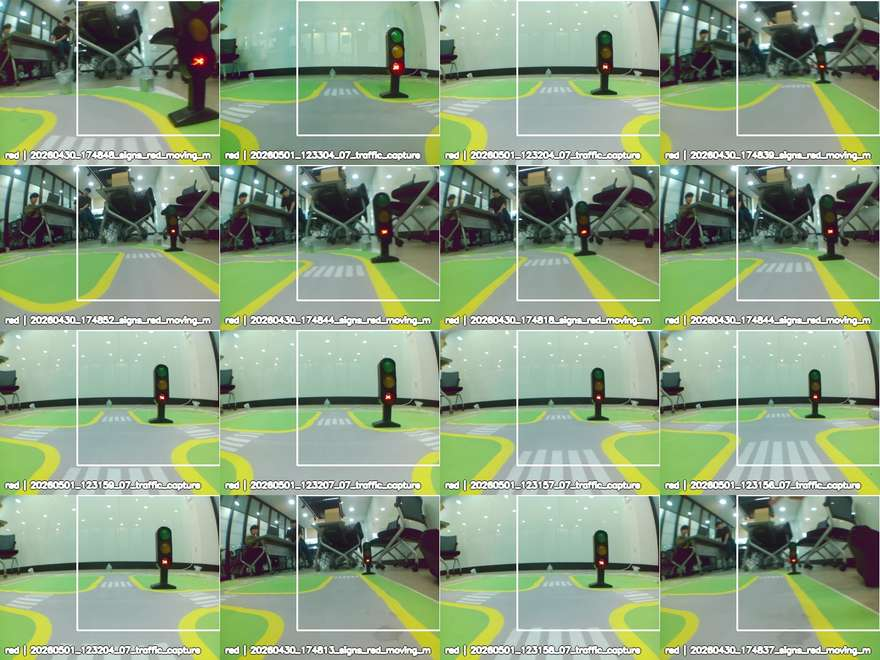

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_green_sample_grid_with_analysis_crop.jpg


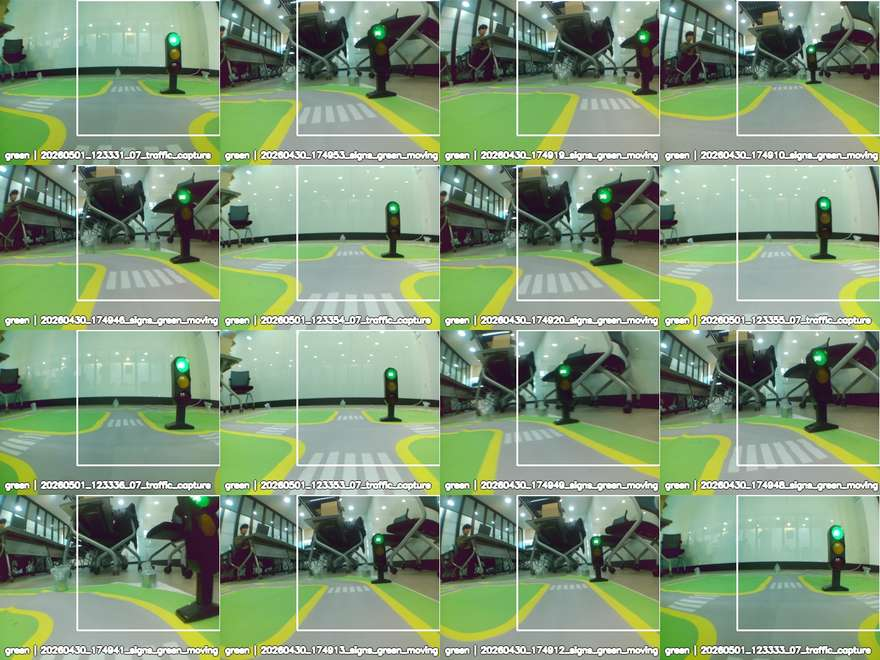

In [5]:
def crop_rect_from_ratio(img, ratio):
    h, w = img.shape[:2]
    x0 = int(round(w * ratio["x0"]))
    x1 = int(round(w * ratio["x1"]))
    y0 = int(round(h * ratio["y0"]))
    y1 = int(round(h * ratio["y1"]))
    x0, x1 = max(0, x0), min(w, x1)
    y0, y1 = max(0, y0), min(h, y1)
    return x0, y0, x1, y1


def crop_by_ratio(img, ratio):
    x0, y0, x1, y1 = crop_rect_from_ratio(img, ratio)
    return img[y0:y1, x0:x1].copy(), (x0, y0, x1, y1)


def draw_label(img, text, org=(8, 24), scale=0.62, color=(255,255,255), thickness=2):
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale, (0,0,0), thickness+2, cv2.LINE_AA)
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)
    return img


def make_grid(items, out_path, cols=4, tile_w=360, tile_h=270, draw_crop=True):
    tiles = []
    for rec in items:
        bgr = imread_bgr(rec["path"])
        vis = cv2.resize(bgr, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
        if draw_crop:
            x0, y0, x1, y1 = crop_rect_from_ratio(bgr, ANALYSIS_CROP_RATIO)
            sx = tile_w / bgr.shape[1]
            sy = tile_h / bgr.shape[0]
            cv2.rectangle(vis, (int(x0*sx), int(y0*sy)), (int(x1*sx), int(y1*sy)), (255,255,255), 2)
        draw_label(vis, f'{rec["label"]} | {rec["filename"][:34]}', (8, tile_h-12), scale=0.46)
        tiles.append(vis)
    rows = math.ceil(len(tiles) / cols)
    blank = np.zeros((tile_h, tile_w, 3), dtype=np.uint8)
    grid_rows = []
    for r in range(rows):
        row_tiles = tiles[r*cols:(r+1)*cols]
        while len(row_tiles) < cols:
            row_tiles.append(blank.copy())
        grid_rows.append(np.concatenate(row_tiles, axis=1))
    grid = np.concatenate(grid_rows, axis=0)
    imwrite_bgr(out_path, grid)
    return out_path

for label in ["red", "green"]:
    sub = sample_df[sample_df["label"] == label].to_dict("records")[:16]
    out = OVERLAY_DIR / f"traffic_{label}_sample_grid_with_analysis_crop.jpg"
    make_grid(sub, out, cols=4)
    print(out)
    show_saved_image(out, width=1100)

## 색공간 채널 montage

여기서는 몇 장의 샘플에 대해 색공간별 채널을 직접 눈으로 본다.

각 샘플마다 다음을 보여준다.

- Original BGR/RGB 보기
- HSV: H/S/V
- HLS: H/L/S
- YCrCb: Y/Cr/Cb
- LAB: L/a/b

판단 포인트:

- 신호등 불빛이 어떤 채널에서 배경보다 밝거나 진하게 튀는가?
- red와 green이 같은 채널에서 반대 방향으로 갈라지는가?
- yellow lane, 흰 반사광, 벽 조명이 같이 튀는 채널은 무엇인가?

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_red_color_space_channel_montage.jpg


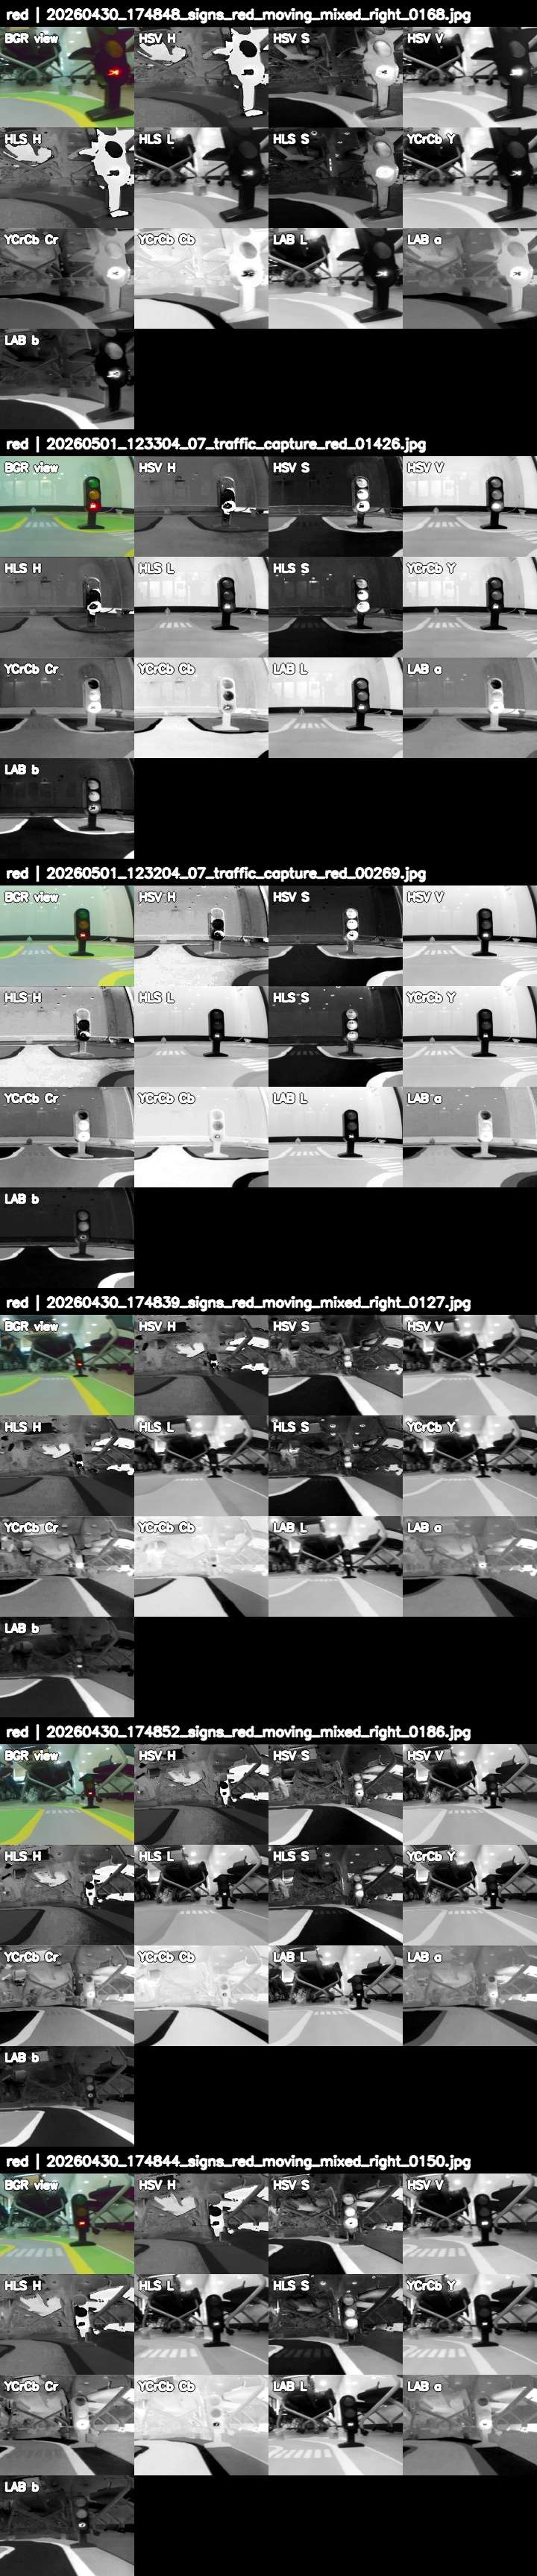

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_green_color_space_channel_montage.jpg


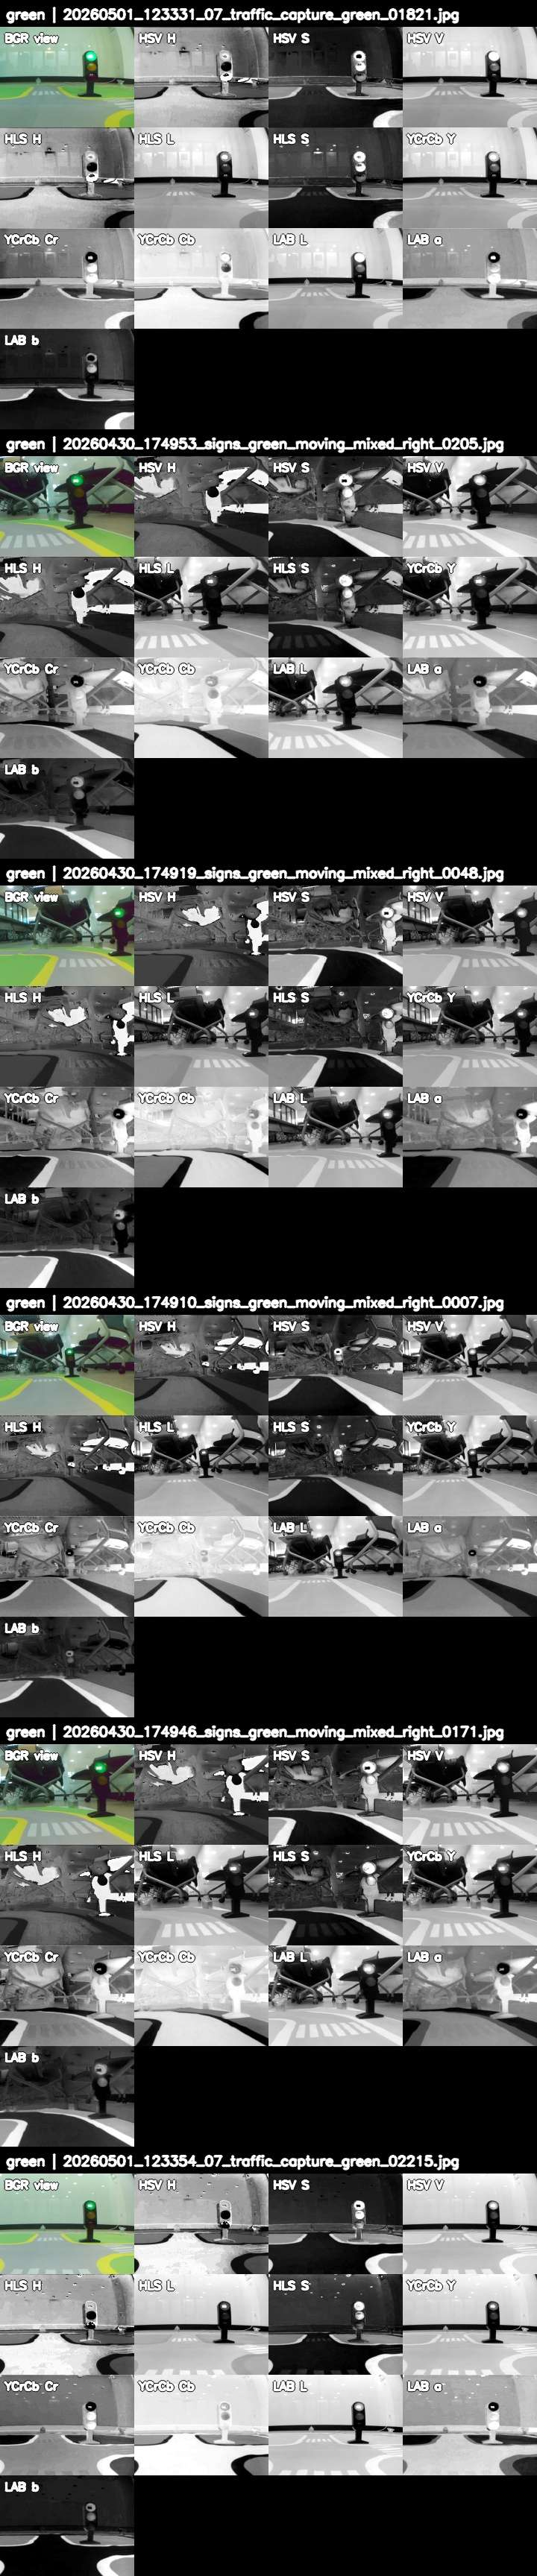

In [6]:
def normalize_gray_for_display(ch):
    ch = ch.astype(np.float32)
    lo = np.percentile(ch, 1)
    hi = np.percentile(ch, 99)
    if hi <= lo:
        hi = lo + 1.0
    out = np.clip((ch - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    return cv2.cvtColor(out, cv2.COLOR_GRAY2BGR)


def channel_tile(ch, title, tile_w=180, tile_h=135):
    vis = normalize_gray_for_display(ch)
    vis = cv2.resize(vis, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    draw_label(vis, title, (6, 20), scale=0.5)
    return vis


def color_space_montage_for_record(rec, crop=True, tile_w=180, tile_h=135):
    bgr = imread_bgr(rec["path"])
    if crop:
        bgr, _ = crop_by_ratio(bgr, ANALYSIS_CROP_RATIO)
    original = cv2.resize(bgr, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    draw_label(original, "BGR view", (6, 20), scale=0.5)

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hls = cv2.cvtColor(bgr, cv2.COLOR_BGR2HLS)
    ycc = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)

    tiles = [original]
    for arr, prefix, names in [
        (hsv, "HSV", ["H", "S", "V"]),
        (hls, "HLS", ["H", "L", "S"]),
        (ycc, "YCrCb", ["Y", "Cr", "Cb"]),
        (lab, "LAB", ["L", "a", "b"]),
    ]:
        for i, name in enumerate(names):
            tiles.append(channel_tile(arr[:, :, i], f"{prefix} {name}", tile_w, tile_h))

    # 13 tiles -> pad to 4 columns x 4 rows.
    blank = np.zeros((tile_h, tile_w, 3), dtype=np.uint8)
    while len(tiles) < 16:
        tiles.append(blank.copy())
    rows = [np.concatenate(tiles[i:i+4], axis=1) for i in range(0, 16, 4)]
    montage = np.concatenate(rows, axis=0)
    header = np.zeros((36, montage.shape[1], 3), dtype=np.uint8)
    draw_label(header, f'{rec["label"]} | {rec["filename"]}', (8, 25), scale=0.6)
    return np.concatenate([header, montage], axis=0)


def make_montage_sheet(records, out_path, max_items=6):
    blocks = []
    for rec in records[:max_items]:
        blocks.append(color_space_montage_for_record(rec, crop=True))
    sheet = np.concatenate(blocks, axis=0)
    imwrite_bgr(out_path, sheet)
    return out_path

for label in ["red", "green"]:
    recs = sample_df[sample_df["label"] == label].to_dict("records")[:6]
    out = OVERLAY_DIR / f"traffic_{label}_color_space_channel_montage.jpg"
    make_montage_sheet(recs, out, max_items=6)
    print(out)
    show_saved_image(out, width=1100)

## 분포 분석 1: 전체 crop 픽셀 vs salient 픽셀

신호등 불빛은 작다. 그래서 전체 crop 픽셀을 그대로 보면 바닥/벽/차선이 대부분이다.

그래서 두 가지 분포를 같이 저장한다.

1. `crop_random`: 분석 crop 안에서 무작위 픽셀 샘플
2. `salient_sv`: 분석 crop 안에서 `S * V`가 높은 픽셀 샘플

`salient_sv`는 최종 detector가 아니다. 색이 강하고 밝은 픽셀을 우선 관찰하기 위한 통계 장치다.

In [7]:
def sample_pixels_for_record(rec, max_pixels=MAX_PIXELS_PER_IMAGE):
    bgr = imread_bgr(rec["path"])
    crop, _ = crop_by_ratio(bgr, ANALYSIS_CROP_RATIO)
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    hls = cv2.cvtColor(crop, cv2.COLOR_BGR2HLS)
    ycc = cv2.cvtColor(crop, cv2.COLOR_BGR2YCrCb)
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)

    h, w = crop.shape[:2]
    flat_n = h * w

    # Random crop pixels: background-dominated baseline.
    n_rand = min(max_pixels, flat_n)
    rand_idx = np.random.choice(flat_n, size=n_rand, replace=False)

    # Salient pixels: high saturation * brightness pixels.
    s = hsv[:, :, 1].astype(np.float32)
    v = hsv[:, :, 2].astype(np.float32)
    score = (s / 255.0) * (v / 255.0)
    cutoff = np.percentile(score, 100.0 - SALIENT_PIXEL_TOP_PERCENT)
    salient_idx = np.flatnonzero(score.reshape(-1) >= cutoff)
    if len(salient_idx) > max_pixels:
        salient_idx = np.random.choice(salient_idx, size=max_pixels, replace=False)

    def gather(indices, mode):
        y = indices // w
        x = indices % w
        return pd.DataFrame({
            "label": rec["label"],
            "filename": rec["filename"],
            "mode": mode,
            "b": crop[y, x, 0],
            "g": crop[y, x, 1],
            "r": crop[y, x, 2],
            "hsv_h": hsv[y, x, 0],
            "hsv_s": hsv[y, x, 1],
            "hsv_v": hsv[y, x, 2],
            "hls_h": hls[y, x, 0],
            "hls_l": hls[y, x, 1],
            "hls_s": hls[y, x, 2],
            "ycc_y": ycc[y, x, 0],
            "ycc_cr": ycc[y, x, 1],
            "ycc_cb": ycc[y, x, 2],
            "lab_l": lab[y, x, 0],
            "lab_a": lab[y, x, 1],
            "lab_b": lab[y, x, 2],
        })

    return pd.concat([
        gather(rand_idx, "crop_random"),
        gather(salient_idx, "salient_sv"),
    ], ignore_index=True)

pixel_dfs = []
# 너무 무거워지지 않도록 label당 24장만 사용한다. 필요하면 SAMPLES_PER_LABEL을 늘리면 된다.
for rec in sample_df.to_dict("records"):
    pixel_dfs.append(sample_pixels_for_record(rec))

pixels_df = pd.concat(pixel_dfs, ignore_index=True)
pixels_df.to_csv(TABLE_DIR / "traffic_color_space_pixel_samples.csv", index=False, encoding="utf-8-sig")
print("pixel samples:", len(pixels_df))
print(pixels_df.groupby(["label", "mode"]).size())
display(pixels_df.head())

pixel samples: 240000
label  mode       
green  crop_random    60000
       salient_sv     60000
red    crop_random    60000
       salient_sv     60000
dtype: int64


,label,filename,mode,b,g,r,hsv_h,hsv_s,hsv_v,hls_h,hls_l,hls_s,ycc_y,ycc_cr,ycc_cb,lab_l,lab_a,lab_b
0,green,20260501_123331_07_traffic_capture_green_01821...,crop_random,179,203,173,66,38,203,66,188,57,191,115,121,202,113,137
1,green,20260501_123331_07_traffic_capture_green_01821...,crop_random,184,204,181,64,29,204,64,193,47,195,118,122,204,116,135
2,green,20260501_123331_07_traffic_capture_green_01821...,crop_random,168,177,144,82,48,177,82,161,45,166,112,129,178,115,129
3,green,20260501_123331_07_traffic_capture_green_01821...,crop_random,139,150,118,80,54,150,80,134,34,139,113,128,152,115,130
4,green,20260501_123331_07_traffic_capture_green_01821...,crop_random,136,149,123,75,44,149,75,136,28,140,116,126,152,116,132


## 분포 분석 2: 채널별 percentile table

아래 표는 각 색공간 채널의 분위수를 저장한다.

평균보다 분위수를 보는 이유는, 신호등 불빛이 작은 영역이라 평균에 잘 드러나지 않기 때문이다.

특히 다음을 본다.

- red의 `HSV H`가 양 끝으로 나뉘는지
- green의 `HSV H`가 특정 범위에 모이는지
- red가 `YCrCb Cr`, `LAB a`에서 튀는지
- green이 `LAB a` 반대 방향 또는 HSV/HLS hue에서 잘 분리되는지

In [8]:
CHANNELS = [
    "b", "g", "r",
    "hsv_h", "hsv_s", "hsv_v",
    "hls_h", "hls_l", "hls_s",
    "ycc_y", "ycc_cr", "ycc_cb",
    "lab_l", "lab_a", "lab_b",
]
PERCENTILES = [1, 5, 10, 25, 50, 75, 90, 95, 99]

rows = []
for (label, mode), sub in pixels_df.groupby(["label", "mode"]):
    row = {"label": label, "mode": mode, "n_pixels": len(sub)}
    for ch in CHANNELS:
        vals = sub[ch].to_numpy(dtype=np.float32)
        for p in PERCENTILES:
            row[f"{ch}_p{p:02d}"] = float(np.percentile(vals, p))
    rows.append(row)

percentile_df = pd.DataFrame(rows)
percentile_df.to_csv(TABLE_DIR / "traffic_color_space_percentiles.csv", index=False, encoding="utf-8-sig")
display(percentile_df)

,label,mode,n_pixels,b_p01,b_p05,b_p10,b_p25,b_p50,b_p75,b_p90,...,lab_a_p99,lab_b_p01,lab_b_p05,lab_b_p10,lab_b_p25,lab_b_p50,lab_b_p75,lab_b_p90,lab_b_p95,lab_b_p99
0,green,crop_random,60000,26.0,33.0,38.0,69.0,129.0,167.0,180.0,...,148.0,119.0,122.949951,127.0,130.0,134.0,140.0,165.0,172.0,195.0
1,green,salient_sv,60000,38.0,42.0,44.0,49.0,66.0,96.0,159.0,...,111.0,118.0,146.000000,156.0,166.0,195.0,199.0,200.0,201.0,201.0
2,red,crop_random,60000,26.0,33.0,39.0,72.0,128.0,172.0,184.0,...,149.0,119.0,123.000000,126.0,129.0,133.0,139.0,165.0,172.0,193.0
3,red,salient_sv,60000,0.0,7.0,23.0,48.0,56.0,73.0,77.0,...,204.0,167.0,175.000000,184.0,194.0,196.0,197.0,199.0,199.0,201.0


## Plot 1: HSV Hue 분포

HSV에서 Hue는 색 종류를 직접 나타낸다. 하지만 OpenCV Hue는 `0~179`이며 red가 양 끝으로 갈라진다.

이 그래프를 볼 때는 다음을 확인한다.

- green은 하나의 봉우리로 모이는가?
- red는 `0` 근처와 `179` 근처에 걸쳐 있는가?
- crop_random에서는 배경 때문에 분포가 흐릿하고, salient_sv에서는 신호등 색이 더 잘 보이는가?

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_hsv_hue_hist_crop_random.png


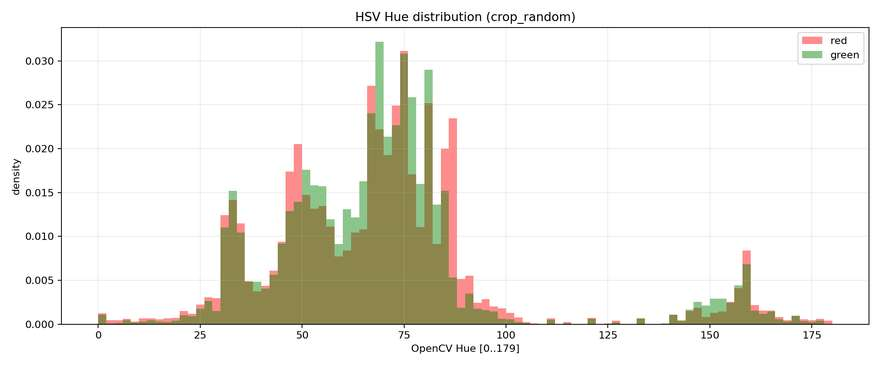

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_hsv_hue_hist_salient_sv.png


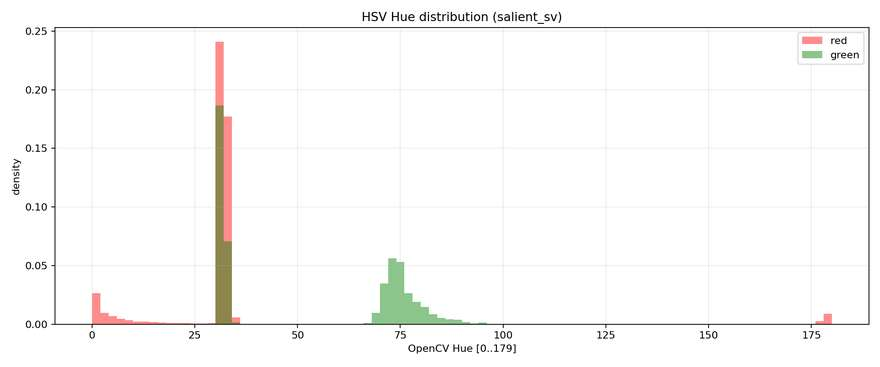

In [9]:
def save_hue_hist(mode, out_path):
    plt.figure(figsize=(12, 5))
    bins = np.arange(0, 181, 2)
    for label, color in [("red", "red"), ("green", "green")]:
        vals = pixels_df[(pixels_df["label"] == label) & (pixels_df["mode"] == mode)]["hsv_h"].to_numpy()
        plt.hist(vals, bins=bins, density=True, alpha=0.45, color=color, label=label)
    plt.title(f"HSV Hue distribution ({mode})")
    plt.xlabel("OpenCV Hue [0..179]")
    plt.ylabel("density")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()
    return out_path

for mode in ["crop_random", "salient_sv"]:
    out = OVERLAY_DIR / f"traffic_hsv_hue_hist_{mode}.png"
    save_hue_hist(mode, out)
    print(out)
    show_saved_image(out, width=900)

## Plot 2: HSV H-S / H-V scatter

Hue만으로는 불안정할 수 있다. 특히 red는 hue가 양 끝으로 갈라지고, 조명 반사가 있으면 saturation이 낮아질 수 있다.

그래서 `H-S`, `H-V`를 같이 본다.

- 좋은 색 조합은 보통 `Hue 범위 + S 최소값 + V 최소값` 형태가 된다.
- 이 셀은 그 조합을 아직 확정하지 않고, 분리 가능성을 눈으로 보는 용도다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_hsv_hs_hv_scatter_salient.png


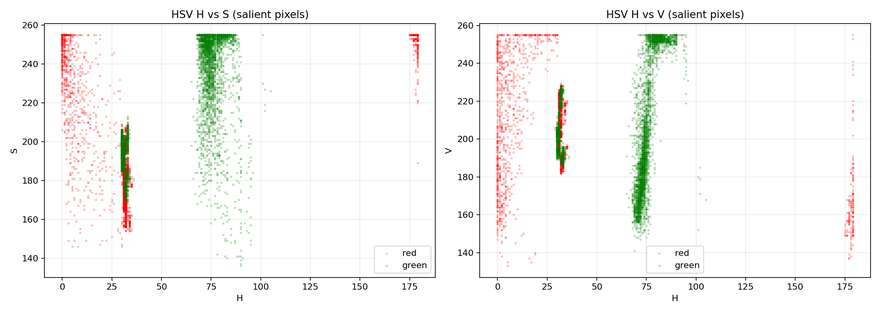

In [10]:
def sample_for_scatter(df, n=12000):
    if len(df) <= n:
        return df
    return df.sample(n=n, random_state=RANDOM_SEED)

for mode in ["salient_sv"]:
    sub = sample_for_scatter(pixels_df[pixels_df["mode"] == mode], n=14000)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label, color in [("red", "red"), ("green", "green")]:
        s = sub[sub["label"] == label]
        axes[0].scatter(s["hsv_h"], s["hsv_s"], s=3, alpha=0.18, c=color, label=label)
        axes[1].scatter(s["hsv_h"], s["hsv_v"], s=3, alpha=0.18, c=color, label=label)
    axes[0].set_title("HSV H vs S (salient pixels)")
    axes[0].set_xlabel("H")
    axes[0].set_ylabel("S")
    axes[1].set_title("HSV H vs V (salient pixels)")
    axes[1].set_xlabel("H")
    axes[1].set_ylabel("V")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    out = OVERLAY_DIR / "traffic_hsv_hs_hv_scatter_salient.png"
    plt.savefig(out, dpi=160)
    plt.close()
    print(out)
    show_saved_image(out, width=1000)

## Plot 3: LAB a-b / YCrCb Cr-Cb scatter

HSV가 1차 후보라면, LAB/YCrCb는 보조 후보가 될 수 있다.

- LAB `a`: green ↔ red 축
- LAB `b`: blue ↔ yellow 축
- YCrCb `Cr`: red 계열 색차
- YCrCb `Cb`: blue/yellow 계열 색차

이 그래프는 나중에 false positive가 많을 때 보조 조건을 만들 수 있는지 확인하기 위한 자료다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\overlays\traffic_lab_ycrcb_scatter_salient.png


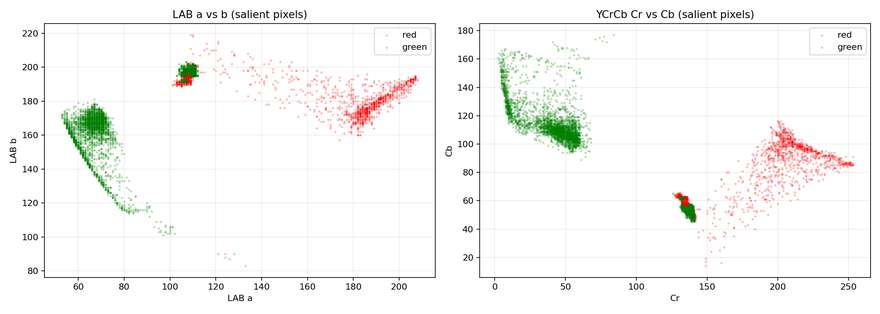

In [11]:
sub = sample_for_scatter(pixels_df[pixels_df["mode"] == "salient_sv"], n=14000)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [("red", "red"), ("green", "green")]:
    s = sub[sub["label"] == label]
    axes[0].scatter(s["lab_a"], s["lab_b"], s=3, alpha=0.18, c=color, label=label)
    axes[1].scatter(s["ycc_cr"], s["ycc_cb"], s=3, alpha=0.18, c=color, label=label)
axes[0].set_title("LAB a vs b (salient pixels)")
axes[0].set_xlabel("LAB a")
axes[0].set_ylabel("LAB b")
axes[1].set_title("YCrCb Cr vs Cb (salient pixels)")
axes[1].set_xlabel("Cr")
axes[1].set_ylabel("Cb")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
out = OVERLAY_DIR / "traffic_lab_ycrcb_scatter_salient.png"
plt.savefig(out, dpi=160)
plt.close()
print(out)
show_saved_image(out, width=1000)

## 색공간 channel별 이미지 저장

그래프만 보면 실제 이미지에서 어떤 부분이 튀는지 놓칠 수 있다. 그래서 신호등 샘플 몇 장에 대해 색공간별 channel montage를 이미지로 저장했다.

다음 단계에서 사람이 확인할 질문:

1. red 신호는 HSV/HLS Hue에서 잘 보이는가?
2. green 신호는 HSV/HLS Hue에서 잘 보이는가?
3. yellow lane이 green 또는 red 후보와 헷갈릴 가능성이 있는가?
4. LAB/YCrCb 보조 채널이 false positive를 줄이는 데 쓸 수 있어 보이는가?
5. 분석 crop이 신호등을 충분히 포함하는가?

이 질문에 답한 뒤에야 threshold 후보 셀을 추가하는 게 맞다.

In [12]:
summary = f'''# 01 Traffic Color Space Probe Notes

## Inputs

- traffic red images: {int((traffic_df['label'] == 'red').sum())}
- traffic green images: {int((traffic_df['label'] == 'green').sum())}
- sample per label: {SAMPLES_PER_LABEL}
- analysis crop ratio: {ANALYSIS_CROP_RATIO}
- salient pixel top percent: {SALIENT_PIXEL_TOP_PERCENT}

## Generated Outputs

### Tables

- `traffic_dataset_index.csv`
- `traffic_color_probe_sample_records.csv`
- `traffic_color_space_pixel_samples.csv`
- `traffic_color_space_percentiles.csv`

### Overlays / Plots

- `traffic_red_sample_grid_with_analysis_crop.jpg`
- `traffic_green_sample_grid_with_analysis_crop.jpg`
- `traffic_red_color_space_channel_montage.jpg`
- `traffic_green_color_space_channel_montage.jpg`
- `traffic_hsv_hue_hist_crop_random.png`
- `traffic_hsv_hue_hist_salient_sv.png`
- `traffic_hsv_hs_hv_scatter_salient.png`
- `traffic_lab_ycrcb_scatter_salient.png`

## What This Notebook Does Not Decide

- final red threshold
- final green threshold
- contour filters
- deployment ROI
- temporal voting
- traffic event trigger

## Review Before Next Step

- Which color space separates red/green most cleanly?
- Does red require two Hue ranges because of wrap-around?
- Is green separated from yellow lane strongly enough in HSV/HLS?
- Do LAB/YCrCb help reject yellow lane or white reflection?
- Should the next notebook include an interactive threshold sandbox for traffic only?
'''
write_text(NOTE_DIR / "01_traffic_color_probe_notes.md", summary)
print(NOTE_DIR / "01_traffic_color_probe_notes.md")

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01_traffic_color_space_probe_v1\notes\01_traffic_color_probe_notes.md


## 다음 단계

이 노트북을 Run All 한 뒤에는 바로 detector를 확정하지 않는다.

먼저 사람이 봐야 하는 산출물은 다음이다.

1. `traffic_hsv_hue_hist_salient_sv.png`
2. `traffic_hsv_hs_hv_scatter_salient.png`
3. `traffic_red_color_space_channel_montage.jpg`
4. `traffic_green_color_space_channel_montage.jpg`

그 결과를 보고 나서 다음 중 하나로 간다.

- HSV만으로 충분하면: traffic threshold sandbox 노트북/셀 추가
- HSV가 불안정하면: HSV + LAB/YCrCb 보조 조건 실험
- yellow lane false positive가 크면: contour/ROI 이전에 색 조건을 더 세분화

즉, 01은 결론이 아니라 **결론을 내리기 위한 관찰 자료 생성**이다.